<div class="alert alert-info">
    <b>Variational Autoencoder (VAE) für Synthetische Datenerzeugung</b><br>
    Implementierung eines Variational Autoencoders zur Generation synthetischer hydrogeochemischer Daten.<br>
    Beinhaltet Analyse und Imputation fehlender Werte.
</div>

In [1]:
# ------------------------- Installation externer Bibliotheken -------------------------
!pip install torch torchvision torchaudio scikit-learn pandas numpy matplotlib seaborn

In [2]:
# ------------------------- Import notwendiger Bibliotheken -------------------------
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------- Globale Plot-Einstellungen -------------------------
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ------------------------- Daten laden -------------------------
# Find the latest preprocessed file
list_of_files = glob.glob('../../3.1_Preprocessing/Preprocessed_SOM_Ready.csv') 
latest_file = max(list_of_files, key=os.path.getctime)
print(f"Lade Datei: {latest_file}")

try:
    # Load with low_memory=False to handle mixed types warning gracefully initially
    data = pd.read_csv(latest_file, low_memory=False)
except FileNotFoundError:
    print("Fehler: Datei nicht gefunden.")

# ------------------------- Temperature Handling -------------------------
# Coerce temperature to numeric, turning errors (like strings) into NaN
if 'temperature_in_c' in data.columns:
    data['temperature_in_c'] = pd.to_numeric(data['temperature_in_c'], errors='coerce')

# ------------------------- Missing Value Analysis -------------------------
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values per Feature')
plt.ylabel('Percentage Missing')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

# Identify and list features with > 95% missing values
features_to_drop = missing_percentage[missing_percentage > 95].index.tolist()
print(f"\nFeatures with > 95% missing values (to be dropped): {features_to_drop}")

print("\nTop 10 features with most missing values:")
print(missing_percentage.sort_values(ascending=False).head(10))

In [3]:
# ------------------------- Pfad definition und Laden der Daten -------------------------
current_dir = os.getcwd()
notebooks_dir = os.path.dirname(os.path.dirname(current_dir))
preprocessing_dir = os.path.join(notebooks_dir, '3.1_Preprocessing', 'Preprocessing')

if not os.path.exists(preprocessing_dir):
    preprocessing_dir = "../../3.1_Preprocessing/Preprocessing"

try:
    # ------------------------- Suche nach neuestem Preprocessing-Ordner -------------------------
    all_subdirs = [os.path.join(preprocessing_dir, d) for d in os.listdir(preprocessing_dir) if os.path.isdir(os.path.join(preprocessing_dir, d))]
    if not all_subdirs:
        raise FileNotFoundError("Keine Preprocessing-Ordner gefunden.")
        
    latest_subdir = max(all_subdirs, key=os.path.getmtime)
    data_path = os.path.join(latest_subdir, 'Preprocessed_SOM_Ready.csv')

    print(f"Lade Daten aus: {data_path}")

    # ------------------------- Einlesen der CSV-Datei -------------------------
    df = pd.read_csv(data_path)
    display(df.head())
    print(f"Datensatzgröße: {df.shape}")

except Exception as e:
    print(f"Fehler beim Laden der Daten: {e}")
    print("Bitte Pfad manuell prüfen.")

Lade Daten aus: C:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\3.1_Preprocessing\Preprocessing\2026-01-04_15-08-43\Preprocessed_SOM_Ready.csv


C:\Users\lucca\AppData\Local\Temp\ipykernel_23880\3733228785.py:21: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


,WGS84_latitude,WGS84_longitude,Database_number,temperature_in_c,rock_type,redox_potential_in_mV_gauss,total_dissolved_solids_in_mmol/L_log_gauss,O2_in_mmol/L_log_gauss,Na_in_mmol/L_log_gauss,Mg_in_mmol/L_log_gauss,...,Li_in_mmol/L_log_gauss,K_in_mmol/L_log_gauss,Sr_in_umol/L_log_gauss,NH4_in_umol/L_log_gauss,Fe_in_mmol/L_log_gauss,Mn_in_mmol/L_log_gauss,F_in_umol/L_log_gauss,NO3_in_mmol/L_log_gauss,H2SiO3_in_umol/L_log_gauss,HS_in_mmol/L_log_gauss
0,46.19680,8.54160,5,25.7,Andesite,NaN,-2.407685,NaN,-2.002380,-2.696511,...,-1.767903,-2.225823,NaN,NaN,NaN,NaN,0.590949,NaN,NaN,NaN
1,46.24352,9.72534,5,37.9,Basalt,NaN,-2.153160,NaN,-1.875864,-2.823144,...,-1.634747,-1.625274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,45.76189,6.96890,5,22.3,Andesite,NaN,-1.933503,NaN,-2.035320,-0.746430,...,-1.404533,-1.674186,NaN,NaN,NaN,NaN,-0.926176,NaN,NaN,NaN
3,46.26274,8.10919,5,29.2,Andesite,NaN,-1.847320,NaN,-3.276940,-0.702315,...,NaN,-1.837975,NaN,NaN,NaN,NaN,-0.926176,NaN,NaN,NaN
4,46.26274,8.10919,5,38.6,Andesite,NaN,-1.732235,NaN,-2.709462,-0.653377,...,NaN,-1.775299,NaN,NaN,NaN,NaN,-0.926176,NaN,NaN,NaN


Datensatzgröße: (94264, 24)


<div class="alert alert-info">
    <b>2. Analyse fehlender Werte</b><br>
    Visualisierung des Anteils fehlender Werte pro Variable.
</div>

C:\Users\lucca\AppData\Local\Temp\ipykernel_23880\2328635694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette='viridis')


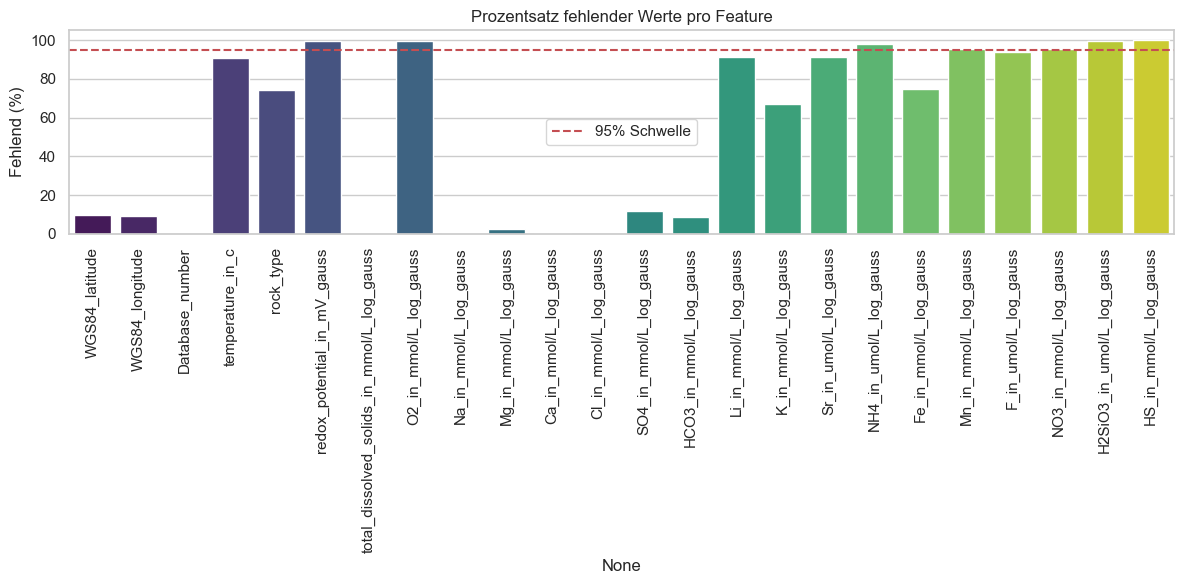

Top 10 Features mit den meisten fehlenden Werten:
HS_in_mmol/L_log_gauss         99.987270
O2_in_mmol/L_log_gauss         99.727361
H2SiO3_in_umol/L_log_gauss     99.604303
redox_potential_in_mV_gauss    99.578842
NH4_in_umol/L_log_gauss        97.981202
Mn_in_mmol/L_log_gauss         95.421370
NO3_in_mmol/L_log_gauss        95.298311
F_in_umol/L_log_gauss          94.051812
Li_in_mmol/L_log_gauss         91.382712
Sr_in_umol/L_log_gauss         91.187516
dtype: float64


In [4]:
# ------------------------- Berechnung des Fehlanteils pro Feature -------------------------
missing_percentage = df.isna().mean() * 100

# ------------------------- Visualisierung als Barplot -------------------------
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette='viridis')
plt.xticks(rotation=90)
plt.title("Prozentsatz fehlender Werte pro Feature")
plt.ylabel("Fehlend (%)")
plt.axhline(95, color='r', linestyle='--', label='95% Schwelle')
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------- Ausgabe der Top 10 Features mit fehlenden Werten -------------------------
print("Top 10 Features mit den meisten fehlenden Werten:")
print(missing_percentage.sort_values(ascending=False).head(10))

<div class="alert alert-info">
    <b>3. Datenvorbereitung und Imputation</b><br>
    1. Entfernen von Spalten mit > 95% fehlenden Werten.<br>
    2. Ausschluss von Metadaten.<br>
    3. Mean-Imputation für verbleibende Lücken.<br>
    4. Standardisierung der Daten.
</div>

In [5]:
# ------------------------- Filterung leerer Spalten (>95% Missing) -------------------------
drop_threshold = 95.0
cols_to_drop = missing_percentage[missing_percentage > drop_threshold].index

if len(cols_to_drop) > 0:
    print(f"\nEntferne Spalten mit >{drop_threshold}% fehlenden Werten: {list(cols_to_drop)}")
    df_clean = df.drop(columns=cols_to_drop)
else:
    df_clean = df
    print("\nKeine Spalten entfernt.")

# ------------------------- Ausschluss von Metadaten -------------------------
cols_to_exclude = ['Database_number', 'database_name', 'Database_name', 'Date', 'Day', 'Month', 'Year']
cols_to_exclude = [c for c in cols_to_exclude if c in df_clean.columns]

if cols_to_exclude:
    print(f"\nEntferne explizit Metadaten-Spalten: {cols_to_exclude}")
    df_clean = df_clean.drop(columns=cols_to_exclude)

# ------------------------- Selektion numerischer Spalten -------------------------
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
data_values = df_clean[numeric_cols].values

# ------------------------- Imputation fehlender Werte (Mean) -------------------------
print("Führe Mean-Imputation für verbleibende NaN-Werte durch...")
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data_values)

# ------------------------- Skalierung (StandardScaler) -------------------------
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# ------------------------- Überprüfung auf NaNs -------------------------
if np.isnan(data_scaled).sum() == 0:
    print("Erfolg: Keine NaNs mehr im Datensatz vorhanden.")
else:
    print("WARNUNG: Immer noch NaNs vorhanden!")

# ------------------------- Erstellung PyTorch Tensoren und DataLoader -------------------------
tensor_data = torch.FloatTensor(data_scaled)

batch_size = 64
dataset = TensorDataset(tensor_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Verwendete Features ({len(numeric_cols)}): {list(numeric_cols)}")


Entferne Spalten mit >95.0% fehlenden Werten: ['redox_potential_in_mV_gauss', 'O2_in_mmol/L_log_gauss', 'NH4_in_umol/L_log_gauss', 'Mn_in_mmol/L_log_gauss', 'NO3_in_mmol/L_log_gauss', 'H2SiO3_in_umol/L_log_gauss', 'HS_in_mmol/L_log_gauss']

Entferne explizit Metadaten-Spalten: ['Database_number']
Führe Mean-Imputation für verbleibende NaN-Werte durch...
Erfolg: Keine NaNs mehr im Datensatz vorhanden.
Verwendete Features (14): ['WGS84_latitude', 'WGS84_longitude', 'total_dissolved_solids_in_mmol/L_log_gauss', 'Na_in_mmol/L_log_gauss', 'Mg_in_mmol/L_log_gauss', 'Ca_in_mmol/L_log_gauss', 'Cl_in_mmol/L_log_gauss', 'SO4_in_mmol/L_log_gauss', 'HCO3_in_mmol/L_log_gauss', 'Li_in_mmol/L_log_gauss', 'K_in_mmol/L_log_gauss', 'Sr_in_umol/L_log_gauss', 'Fe_in_mmol/L_log_gauss', 'F_in_umol/L_log_gauss']


<div class="alert alert-info">
    <b>4. Definition der VAE-Modellarchitektur</b>
</div>

In [6]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=10):
        super(VAE, self).__init__()
        
        # ------------------------- Encoder Architektur -------------------------
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)      # Mittelwert
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)  # Log Varianz
        
        # ------------------------- Decoder Architektur -------------------------
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
        self.activation = nn.ReLU()
        
    def encode(self, x):
        # ------------------------- Forward Pass Encoder -------------------------
        h1 = self.activation(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)
    
    def reparameterize(self, mu, logvar):
        # ------------------------- Reparameterisierungstrick -------------------------
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        # ------------------------- Forward Pass Decoder -------------------------
        h3 = self.activation(self.fc3(z))
        return self.fc4(h3) 
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ------------------------- Modell-Initialisierung -------------------------
input_dim = data_scaled.shape[1]
latent_dim = 8
model = VAE(input_dim, hidden_dim=64, latent_dim=latent_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

<div class="alert alert-info">
    <b>5. Training des Modells</b>
</div>

Epoch 0: Average Loss: 9.0332


Epoch 10: Average Loss: 6.5331


Epoch 20: Average Loss: 6.4074


Epoch 30: Average Loss: 6.3601


Epoch 40: Average Loss: 6.3404


Epoch 50: Average Loss: 6.3120


Epoch 60: Average Loss: 6.3049


Epoch 70: Average Loss: 6.3010


Epoch 80: Average Loss: 6.2894


Epoch 90: Average Loss: 6.2848


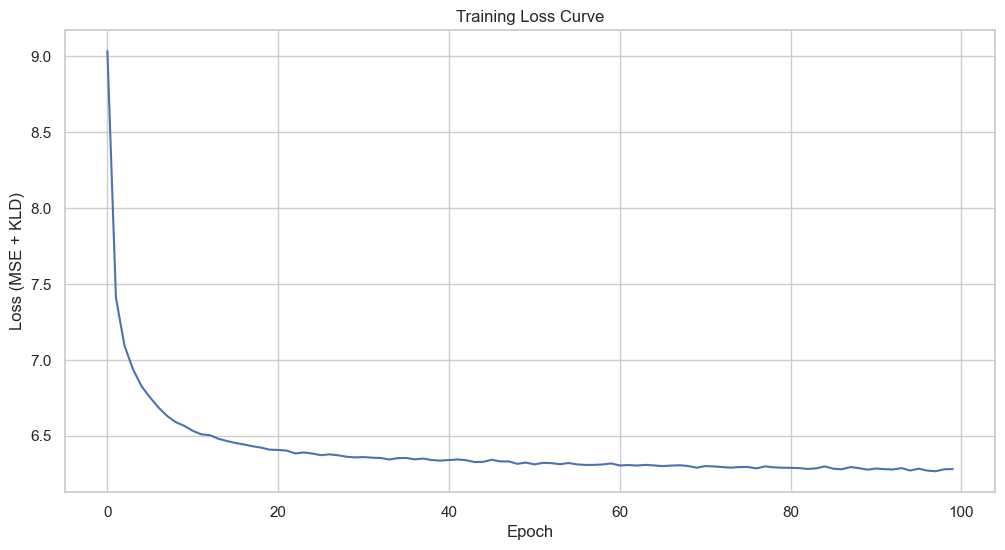

In [7]:
def loss_function(recon_x, x, mu, logvar):
    # ------------------------- Berechnung Loss (MSE + KLD) -------------------------
    MSE = nn.MSELoss(reduction='sum')(recon_x, x)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

epochs = 100
loss_history = []

# ------------------------- Trainingsschleife -------------------------
model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data_batch,) in enumerate(dataloader):
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data_batch)
        loss = loss_function(recon_batch, data_batch, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    avg_loss = train_loss / len(dataloader.dataset)
    loss_history.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}: Average Loss: {avg_loss:.4f}')

# ------------------------- Visualisierung Lernkurve -------------------------
plt.plot(loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE + KLD)')
plt.show()

<div class="alert alert-info">
    <b>6. Generierung und Validierung synthetischer Daten</b>
</div>

In [ ]:
# Save the trained model
torch.save(model.state_dict(), 'vae_model.pth')
print("Model saved successfully.")

# Generate synthetic data
model.eval()
with torch.no_grad():
    # Sample from latent space
    z = torch.randn(num_samples, latent_dim)
    generated_samples_scaled = decoder(z).numpy()

# ------------------------- Inverse Transformation -------------------------
# 1. Inverse Scale
generated_samples_imputed = scaler.inverse_transform(generated_samples_scaled)
generated_df_imputed = pd.DataFrame(generated_samples_imputed, columns=data_imputed.columns)

# 2. Inverse Encode Rock Type
if rock_type_encoder is not None and len(rock_type_cols) > 0:
    # Extract rock type columns
    rock_type_ohe = generated_df_imputed[rock_type_cols]
    
    # We need to find the category with the highest value (argmax) to determine the class
    # But inverse_transform expects the same shape. Simplest way for OHE is argmax then map back.
    # However, sklearn's inverse_transform works on the array directly if it was OHE.
    # Because our OHE columns are at the end (or specific positions), we might need to be careful.
    
    # Let's try direct inverse transform on the OHE part
    rock_types_restored = rock_type_encoder.inverse_transform(rock_type_ohe.values)
    
    # Create the final DataFrame
    final_synthetic_data = generated_df_imputed.drop(columns=rock_type_cols)
    final_synthetic_data['rock_type'] = rock_types_restored
else:
    final_synthetic_data = generated_df_imputed

# ------------------------- Save generated data -------------------------
final_synthetic_data.to_csv('Synthetic_Hydrogeochemistry_Data_Imputed.csv', index=False)
print("Synthetic data saved successfully with original units and categories.")

# Optional: Visualize first few rows
print(final_synthetic_data.head())